<a href="https://colab.research.google.com/github/MoussaCodeur/MoussaCodeur/blob/main/mnist_image_similarity_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Taille de X : (70000, 28, 28)
Taille de Y : (70000,)

Image de référence
Indice : 61579
Classe : 6
Taille de IR avant flatten : (28, 28)
Taille de IR après flatten : (784,)

Les 3 images les plus proches :
Indice : 67210 | Distance : 1014.5057910135358 | Classe : 6
Indice : 31588 | Distance : 1089.7040882735093 | Classe : 6
Indice : 60457 | Distance : 1156.571657961581 | Classe : 6


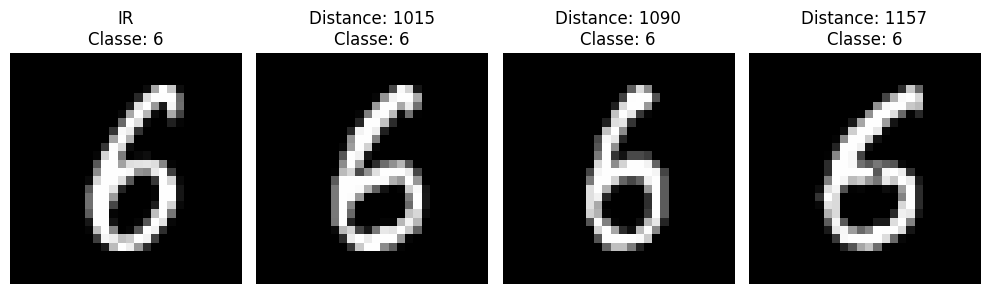

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist


# ============================================================
# 1. Chargement du dataset MNIST
# ============================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()


# ============================================================
# 2. Fusionner les données train et test
# ============================================================

X = np.concatenate((x_train, x_test))
Y = np.concatenate((y_train, y_test))

print("Taille de X :", X.shape)
print("Taille de Y :", Y.shape)


# ============================================================
# 3. Choisir une image aléatoire IR
# ============================================================

indice_IR = np.random.randint(0, len(X))

IR = X[indice_IR]
label_IR = Y[indice_IR]

print("\nImage de référence")
print("Indice :", indice_IR)
print("Classe :", label_IR)


# ============================================================
# 4. Aplatir l'image IR
# ============================================================

IR_flatten = IR.flatten()

print("Taille de IR avant flatten :", IR.shape)
print("Taille de IR après flatten :", IR_flatten.shape)


# ============================================================
# 5. Calculer les distances entre IR et toutes les images
# ============================================================

distances = []

for i in range(len(X)):

    # Ne pas comparer IR avec elle-même
    if i == indice_IR:
        continue

    # Aplatir l'image IB
    IB_flatten = X[i].flatten()

    # Distance euclidienne
    distance = math.dist(IR_flatten, IB_flatten)

    # Sauvegarder distance + indice
    distances.append((distance, i))


# ============================================================
# 6. Trier les distances par ordre croissant
# ============================================================

distances.sort(key=lambda x: x[0])


# ============================================================
# 7. Sélectionner les 3 images les plus proches
# ============================================================

trois_plus_proches = distances[:3]

print("\nLes 3 images les plus proches :")

for distance, indice in trois_plus_proches:

    print(
        "Indice :", indice,
        "| Distance :", distance,
        "| Classe :", Y[indice]
    )


# ============================================================
# 8. Afficher IR et les 3 images les plus proches
# ============================================================

plt.figure(figsize=(10, 3))


# Image de référence
plt.subplot(1, 4, 1)
plt.imshow(IR, cmap="gray")
plt.title(f"IR\nClasse: {label_IR}")
plt.axis("off")


# Images les plus proches
for j, (distance, indice) in enumerate(trois_plus_proches):

    plt.subplot(1, 4, j + 2)

    plt.imshow(X[indice], cmap="gray")

    plt.title(
        f"Distance: {distance:.0f}\n"
        f"Classe: {Y[indice]}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()